# Análise de Risco de Vulnerabilidades

- Severidade de referência: derivada do CVSS `severidade_corrigida`, pois a severidade manual diverge do score em cerca de 74% dos registros.
- Exposição = vulnerabilidades **não corrigidas** (`Aberta`, `Em tratamento` e `Aceita`).
- Vulnerabilidades de ativos inexistentes no inventário (`A9999`) entram nos totais, mas ficam fora dos rankings por ativo.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df_ativos = pd.read_csv(r'..\data\processed\ativos_limpo.csv', sep=';')
vulnerabilidades_df = pd.read_csv(r'..\data\processed\vulnerabilidades_limpo.csv', sep=';')

ORDEM_SEV = ['Baixa', 'Média', 'Alta', 'Crítica']
ORDEM_CRIT = ['Baixa', 'Média', 'Alta', 'Crítica', 'Não Mapeado']
CORES_SEV = {'Baixa': 'green', 'Média': 'yellow', 'Alta': 'orange', 'Crítica': 'red'}

In [3]:
display(vulnerabilidades_df.head())

,vuln_id,ativo_id,severidade_corrigida,cvss_score,origem,status_vulnerabilidade,data_abertura,data_correcao,sistema,criticidade_ativo,ambiente,status_ativo,ativo_id_1,dominio,localidade,flag_ativo_orfao,flag_data_abertura_invalida,flag_data_correcao_futura,flag_erro_data_sla,dias_para_correcao
0,V00001,A0078,Baixa,2.8,Cloud Security,Em tratamento,2026-03-21,NaN,Sistema_78,Crítica,Homologação,Ativo,A0078,Dominio_7,São Paulo,False,False,NaN,0,NaN
1,V00002,A0060,Alta,7.5,Qualys,Em tratamento,2026-06-01,NaN,Sistema_60,Média,Não Mapeado,Ativo,A0060,Dominio_1,Curitiba,False,False,NaN,0,NaN
2,V00003,A0080,Baixa,1.7,Veracode,Aberta,2026-08-18,NaN,Sistema_80,Crítica,Produção,Ativo,A0080,Dominio_9,Recife,False,False,NaN,0,NaN
3,V00004,A0086,Baixa,2.5,Qualys,Aberta,2026-06-16,NaN,Sistema_86,Média,Produção,Ativo,A0086,Dominio_3,Recife,False,False,NaN,0,NaN
4,V00005,A0089,Média,4.4,Cloud Security,Em tratamento,2026-02-12,NaN,Sistema_89,Média,Produção,Ativo,A0089,Dominio_6,Recife,False,False,NaN,0,NaN


## Carregando dados

In [29]:
vulnerabilidades_df['data_abertura'] = pd.to_datetime(vulnerabilidades_df['data_abertura'])
vulnerabilidades_df['data_correcao'] = pd.to_datetime(vulnerabilidades_df['data_correcao'])

vulnerabilidades_df['flag_data_correcao_futura'] = vulnerabilidades_df['flag_data_correcao_futura'].fillna(False).astype(bool)

vulnerabilidades_df['aberta'] = vulnerabilidades_df['status_vulnerabilidade'] != 'Corrigida'

vulnerabilidades_df['idade_dias'] = np.where(vulnerabilidades_df['aberta'], (pd.Timestamp.today() - vulnerabilidades_df['data_abertura']).dt.days, np.nan)

abertas = vulnerabilidades_df[vulnerabilidades_df['aberta']]

## Qual é o nível atual de exposição ao risco?
### Indicadores gerais

In [5]:
kpis = {
    'Total de vulnerabilidades': len(vulnerabilidades_df),
    'Sem correção (exposição)': vulnerabilidades_df.aberta.sum(),
    '% sem correção': f"{len(abertas)/len(vulnerabilidades_df):.1%}",
    'Críticas sem correção (CVSS >= 9)': int((abertas.cvss_score >= 9).sum()),
    'Altas ou críticas sem correção (CVSS >= 7)': int((abertas.cvss_score >= 7).sum()),
    'CVSS >= 9 em Produção': int(((abertas.cvss_score >= 9) & (abertas.ambiente == 'Produção')).sum()),
    'CVSS médio do backlog': round(abertas.cvss_score.mean(), 2),
    'Idade mediana do backlog (dias)': int(abertas.idade_dias.median()),
    'Backlog com mais de 90 dias': f"{(abertas.idade_dias > 90).mean():.1%}",
    'Backlog com mais de 180 dias': f"{(abertas.idade_dias > 180).mean():.1%}",
}
pd.Series(kpis, name='valor').to_frame().reset_index()

,index,valor
0,Total de vulnerabilidades,2000
1,Sem correção (exposição),1531
2,% sem correção,76.5%
3,Críticas sem correção (CVSS >= 9),172
4,Altas ou críticas sem correção (CVSS >= 7),466
5,CVSS >= 9 em Produção,57
6,CVSS médio do backlog,5.05
7,Idade mediana do backlog (dias),147
8,Backlog com mais de 90 dias,70.5%
9,Backlog com mais de 180 dias,37.2%


### Distribuição do backlog por status e severidade

C:\Users\mortal\AppData\Local\Temp\ipykernel_15064\4052028910.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont.index, y=cont.values, palette=['red', 'orange', 'yellow', 'green'], ax=ax[0])


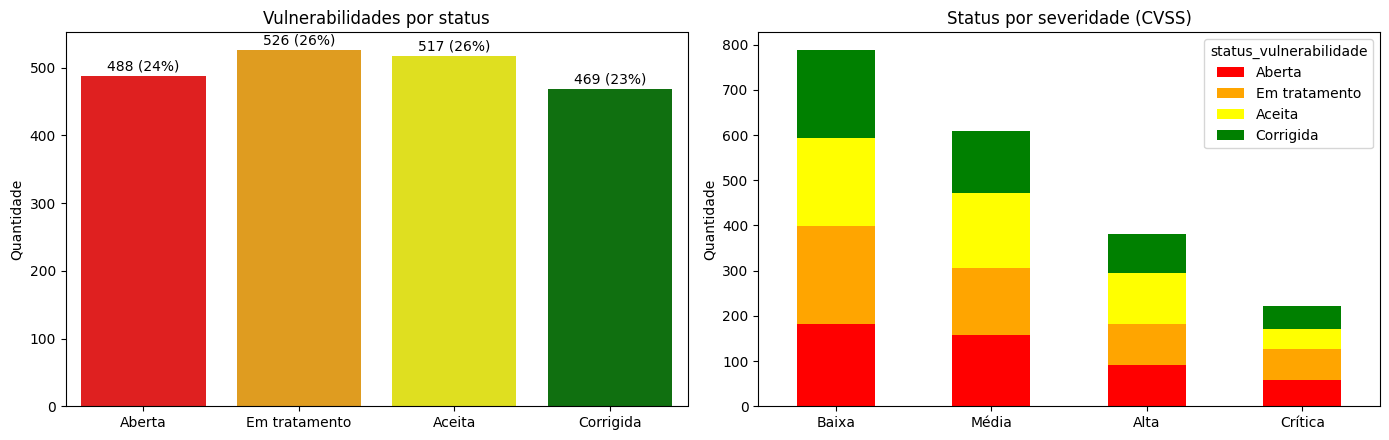

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ordem_status = ['Aberta', 'Em tratamento', 'Aceita', 'Corrigida']
cont = vulnerabilidades_df['status_vulnerabilidade'].value_counts().reindex(ordem_status)
sns.barplot(x=cont.index, y=cont.values, palette=['red', 'orange', 'yellow', 'green'], ax=ax[0])
for i, v in enumerate(cont.values):
    ax[0].text(i, v + 8, f'{v} ({v/len(vulnerabilidades_df):.0%})', ha='center')
ax[0].set_title('Vulnerabilidades por status'); ax[0].set_xlabel(''); ax[0].set_ylabel('Quantidade')

tab = pd.crosstab(vulnerabilidades_df['severidade_corrigida'], vulnerabilidades_df['status_vulnerabilidade']).reindex(index=ORDEM_SEV, columns=ordem_status)
tab.plot(kind='bar', stacked=True, ax=ax[1], color=['red', 'orange', 'yellow', 'green'])
ax[1].set_title('Status por severidade (CVSS)'); ax[1].set_xlabel(''); ax[1].set_ylabel('Quantidade')
ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

### Tempo aberto
Quanto mais antigo o item, maior a janela de exploração. A tabela cruza faixa de idade e severidade.

severidade_corrigida,Baixa,Média,Alta,Crítica,Total
idade_dias,,,,,
0-30,40,20,13,9,82
31-60,58,45,38,23,164
61-90,72,53,27,18,170
91-180,203,158,89,60,510
> 180,209,185,115,60,569


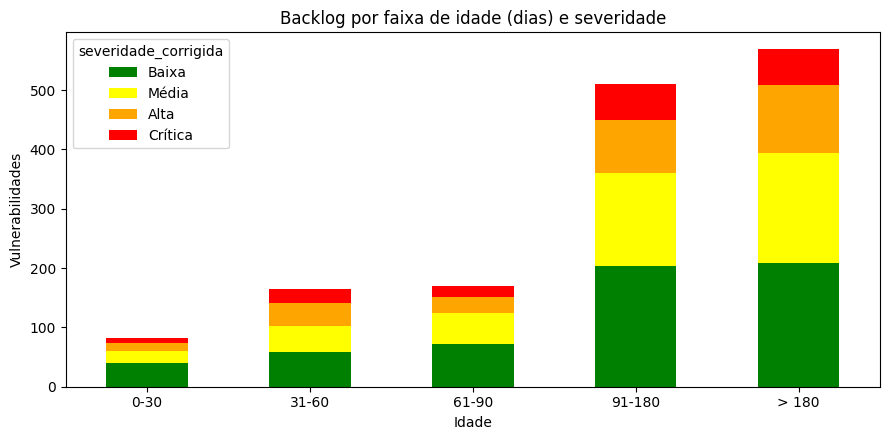

In [7]:
faixas = pd.cut(abertas['idade_dias'], [-1, 30, 60, 90, 180, 400], labels=['0-30', '31-60', '61-90', '91-180', '> 180'])
aging = pd.crosstab(faixas, abertas['severidade_corrigida']).reindex(columns=ORDEM_SEV)
display(aging.assign(Total=aging.sum(axis=1)))

aging.plot(kind='bar', stacked=True, figsize=(9, 4.5), color=[CORES_SEV[s] for s in ORDEM_SEV])
plt.title('Backlog por faixa de idade (dias) e severidade'); plt.xlabel('Idade'); plt.ylabel('Vulnerabilidades')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### Observações:
A maior parte das vulnerabilidades estão sem correção e abertas a mais de 90 dias, apontando que o processo não está acompanhando a volumetria de vulnerabilidades

Com ponto de maior urgência sendo as 57 críticas em produção, exigindo um plano de contenção

Gargalo na esteira de correção com apenas 23% corrigidas e com 26% e tratamento


### Perguntas:
Por que nossa equipe não consegue acompanhar a volumetria de vulnerabilidades?

Qual o motivo para termos um volume tão alto de vulnerabilidades críticas?

Quem está assumindo a responsabilidade pelas vulnerabilidades P1?

Por que vulnerabilidades críticas ainda estão como abertas enquanto alocamos esforços para vulnerabilidades com severidade baixa?


### Distribuição do CVSS no backlog

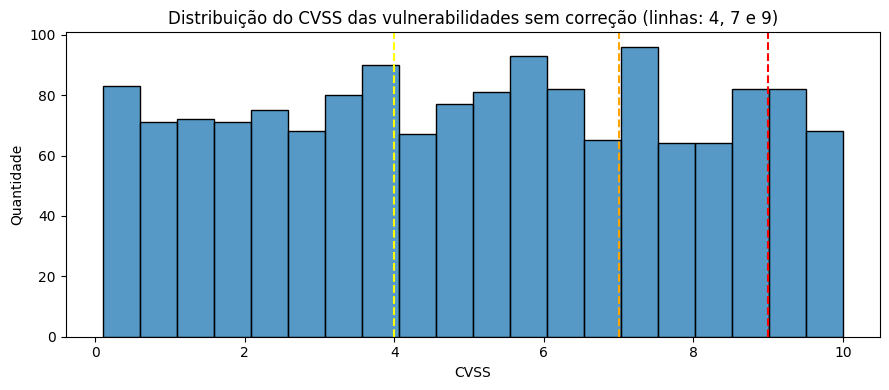

In [8]:
plt.figure(figsize=(9, 4))
sns.histplot(abertas['cvss_score'], bins=20)
for x, c in [(4, 'yellow'), (7, 'orange'), (9, 'red')]:
    plt.axvline(x, color=c, linestyle='--')
plt.title('Distribuição do CVSS das vulnerabilidades sem correção (linhas: 4, 7 e 9)')
plt.xlabel('CVSS'); plt.ylabel('Quantidade'); plt.tight_layout(); plt.show()

## Quais ativos demandam maior atenção?
Foi construído um score de risco por ativo, somando para cada vulnerabilidade sem correção:

`CVSS × peso da criticidade do ativo × fator de ambiente`

- Peso de criticidade: Crítica = 4, Alta = 3, Média = 2, Baixa = 1 (sem classificação = 2).
- Fator de ambiente: Produção = 1,5; demais = 1,0.

Os pesos são premissas de negócio e podem ser ajustados.

In [9]:
PESO_CRIT = {'Crítica': 4, 'Alta': 3, 'Média': 2, 'Baixa': 1, 'Não Mapeado': 2}
base = abertas[~abertas['flag_ativo_orfao']].copy()
base['peso_crit'] = base['criticidade_ativo'].map(PESO_CRIT)
base['fator_amb'] = np.where(base['ambiente'] == 'Produção', 1.5, 1.0)
base['score'] = base['cvss_score'] * base['peso_crit'] * base['fator_amb']

ranking = (base.groupby('ativo_id').agg(
    sistema=('sistema', 'first'), criticidade=('criticidade_ativo', 'first'), ambiente=('ambiente', 'first'),
    dominio=('dominio', 'first'), localidade=('localidade', 'first'), status_ativo=('status_ativo', 'first'),
    qtd_abertas=('vuln_id', 'size'), qtd_cvss_7_mais=('cvss_score', lambda s: int((s >= 7).sum())),
    cvss_max=('cvss_score', 'max'), idade_mediana=('idade_dias', 'median'), score=('score', 'sum')
    ).sort_values('score', ascending=False))
ranking['score_acum_%'] = ranking['score'].cumsum() / ranking['score'].sum()
ranking.head(15).round(1)

,sistema,criticidade,ambiente,dominio,localidade,status_ativo,qtd_abertas,qtd_cvss_7_mais,cvss_max,idade_mediana,score,score_acum_%
ativo_id,,,,,,,,,,,,
A0120,Sistema_120,Alta,Produção,Dominio_1,São Paulo,Ativo,15,6,10.0,190.0,365.0,0.0
A0184,Sistema_184,Crítica,Produção,Dominio_5,Recife,Em desativação,9,6,9.3,125.0,364.8,0.0
A0173,Sistema_173,Alta,Produção,Dominio_6,Campinas,Ativo,14,5,8.9,139.0,328.5,0.0
A0116,Sistema_116,Crítica,Produção,Dominio_9,Campinas,Ativo,10,3,7.7,131.0,322.2,0.1
A0087,Sistema_87,Alta,Produção,Dominio_4,Recife,Ativo,10,6,9.2,130.0,293.8,0.1
A0148,Sistema_148,Alta,Produção,Dominio_5,São Paulo,Ativo,11,5,10.0,205.0,291.2,0.1
A0102,Sistema_102,Crítica,Produção,Dominio_7,São Paulo,Ativo,9,3,9.6,172.0,286.8,0.1
A0111,Sistema_111,Crítica,Produção,Dominio_4,Curitiba,Ativo,9,4,9.8,158.0,283.8,0.1
A0181,Sistema_181,Crítica,Produção,Dominio_2,Campinas,Em desativação,8,3,9.8,165.5,277.8,0.1


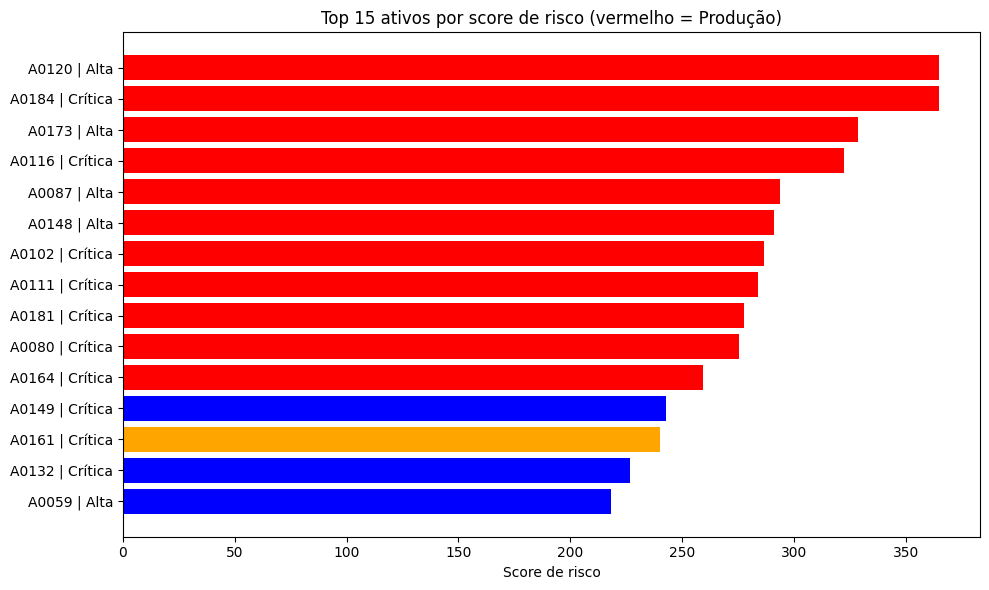

In [10]:
top = ranking.head(15).iloc[::-1]
cores = top['ambiente'].map({'Produção': 'red', 'Homologação': 'orange', 'Desenvolvimento': 'blue'}).fillna('#757575')
plt.figure(figsize=(10, 6))
plt.barh(top.index + ' | ' + top['criticidade'], top['score'], color=cores)
plt.title('Top 15 ativos por score de risco (vermelho = Produção)')
plt.xlabel('Score de risco'); plt.tight_layout(); plt.show()

### Ativos críticos em Produção com vulnerabilidades graves
Combinação de maior impacto: ativos classificados como `Crítica` ou `Alta`, em Produção, com CVSS >= 7 sem correção.

In [11]:
graves = base[(base.criticidade_ativo.isin(['Crítica', 'Alta'])) & (base.ambiente == 'Produção') & (base.cvss_score >= 7)]
res = (graves.groupby(['ativo_id', 'sistema', 'criticidade_ativo', 'status_ativo'])
       .agg(qtd=('vuln_id', 'size'), cvss_max=('cvss_score', 'max'), idade_max_dias=('idade_dias', 'max'))
       .sort_values(['qtd', 'cvss_max'], ascending=False).reset_index())
print(f'{len(graves)} vulnerabilidades em {res.ativo_id.nunique()} ativos')
res.head(15)

86 vulnerabilidades em 27 ativos


,ativo_id,sistema,criticidade_ativo,status_ativo,qtd,cvss_max,idade_max_dias
0,A0120,Sistema_120,Alta,Ativo,6,10.0,219.0
1,A0184,Sistema_184,Crítica,Em desativação,6,9.3,270.0
2,A0087,Sistema_87,Alta,Ativo,6,9.2,232.0
3,A0148,Sistema_148,Alta,Ativo,5,10.0,256.0
4,A0173,Sistema_173,Alta,Ativo,5,8.9,276.0
5,A0111,Sistema_111,Crítica,Ativo,4,9.8,229.0
6,A0093,Sistema_93,Alta,Ativo,4,9.7,269.0
7,A0178,Sistema_178,Alta,Ativo,4,9.0,246.0
8,A0008,Sistema_8,Alta,Ativo,3,9.9,199.0
9,A0151,Sistema_151,Crítica,Ativo,3,9.9,198.0


## Onde devem ser priorizados os esforços de correção?
### Mapa de calor: criticidade do ativo × severidade da vulnerabilidade
Os quadrantes superiores direitos (ativo crítico e vulnerabilidade crítica) devem ser tratados primeiro.

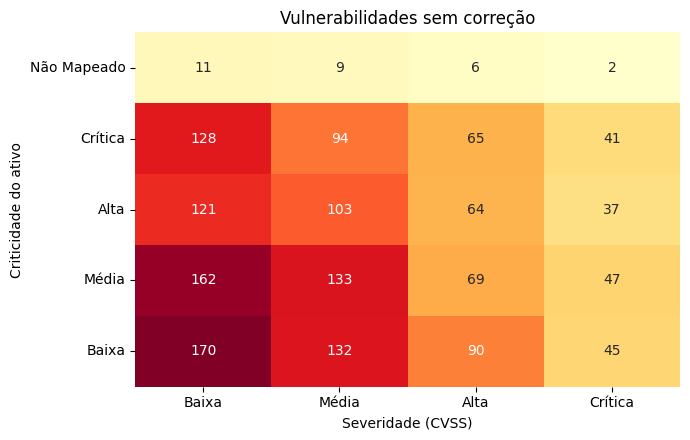

In [12]:
mapa = pd.crosstab(base['criticidade_ativo'], base['severidade_corrigida']).reindex(index=ORDEM_CRIT[::-1], columns=ORDEM_SEV).fillna(0)
plt.figure(figsize=(7, 4.5))
sns.heatmap(mapa, annot=True, fmt='.0f', cmap='YlOrRd', cbar=False)
plt.title('Vulnerabilidades sem correção'); plt.xlabel('Severidade (CVSS)'); plt.ylabel('Criticidade do ativo')
plt.tight_layout(); plt.show()

### Fila de priorização (P1 a P4)
Regra proposta para organizar a remediação:

| Prioridade | Critério |
|---|---|
| **P1** | CVSS >= 9 em Produção, ou CVSS >= 7 em ativo `Crítica` de Produção |
| **P2** | CVSS >= 7 em Produção, ou CVSS >= 9 em outros ambientes |
| **P3** | Demais casos com CVSS >= 7 |
| **P4** | CVSS < 7 |

C:\Users\mortal\AppData\Local\Temp\ipykernel_15064\3675469005.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abertas['prioridade'] = abertas.apply(prioridade, axis=1)


,qtd,ativos,idade_mediana,aceitas,em_desativacao,% do backlog
prioridade,,,,,,
P1,75,44,124.5,20,15,4.9%
P2,211,126,148.0,64,41,13.8%
P3,180,103,143.0,73,60,11.8%
P4,1065,200,147.5,360,258,69.6%


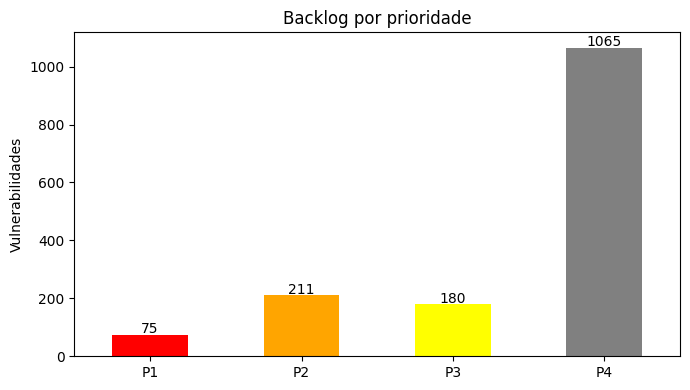

In [13]:
def prioridade(r):
    prod = r.ambiente == 'Produção'
    if (r.cvss_score >= 9 and prod) or (r.cvss_score >= 7 and prod and r.criticidade_ativo == 'Crítica'): return 'P1'
    if (r.cvss_score >= 7 and prod) or r.cvss_score >= 9: return 'P2'
    if r.cvss_score >= 7: return 'P3'
    return 'P4'

abertas['prioridade'] = abertas.apply(prioridade, axis=1)
fila = abertas.groupby('prioridade').agg(
    qtd=('vuln_id', 'size'), ativos=('ativo_id', 'nunique'), idade_mediana=('idade_dias', 'median'),
    aceitas=('status_vulnerabilidade', lambda s: int((s == 'Aceita').sum())),
    em_desativacao=('status_ativo', lambda s: int((s == 'Em desativação').sum())))
fila['% do backlog'] = (fila.qtd / fila.qtd.sum()).map('{:.1%}'.format)
display(fila)

ax = fila['qtd'].plot(kind='bar', color=['red', 'orange', 'yellow', 'gray'], figsize=(7, 4))
for i, v in enumerate(fila['qtd']): ax.text(i, v + 5, v, ha='center')
plt.title('Backlog por prioridade'); plt.xlabel(''); plt.ylabel('Vulnerabilidades'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

### Observações:
Existe um risco onde a equipe pode estar gastando muito tempo tentando limpar o volume, se concentrando em vulnerabilidades de baixa Criticidade e deixando falhas críticas abertas

Podemos observar que a idade mediana de P1 e P2 está próxima de P3 e P4, apontando que a equipe não está diferenciando a urgência

### Risco por domínio, localidade e ambiente

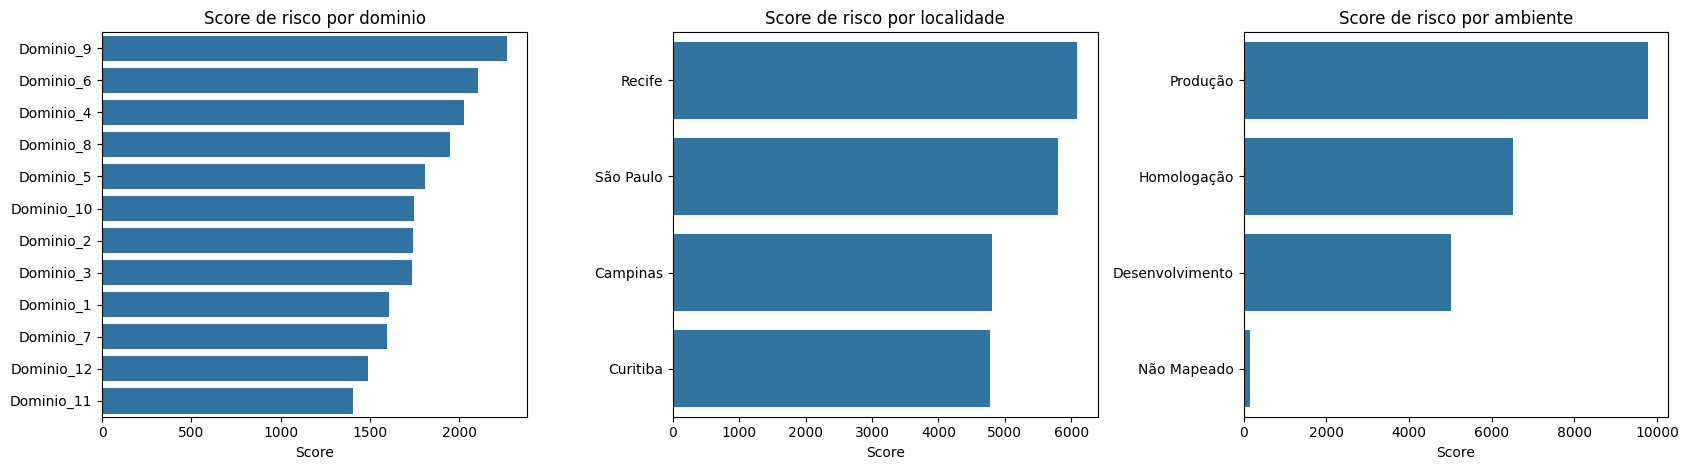

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for a, col in zip(ax, ['dominio', 'localidade', 'ambiente']):
    g = base.groupby(col)['score'].sum().sort_values(ascending=False)
    sns.barplot(x=g.values, y=g.index, ax=a)
    a.set_title(f'Score de risco por {col}'); a.set_xlabel('Score'); a.set_ylabel('')
plt.tight_layout(); plt.show()

In [15]:
(base.groupby('dominio')
     .agg(qtd=('vuln_id', 'size'), cvss_7_mais=('cvss_score', lambda s: int((s >= 7).sum())), ativos=('ativo_id', 'nunique'), score=('score', 'sum'))
     .assign(score_por_ativo=lambda d: d.score / d.ativos)
     .sort_values('score', ascending=False).round(1))

,qtd,cvss_7_mais,ativos,score,score_por_ativo
dominio,,,,,
Dominio_9,131,39,17,2267.6,133.4
Dominio_6,143,34,17,2106.8,123.9
Dominio_4,133,39,17,2029.2,119.4
Dominio_8,125,43,17,1951.8,114.8
Dominio_5,114,35,17,1811.1,106.5
Dominio_10,132,42,16,1744.8,109.0
Dominio_2,127,37,17,1739.2,102.3
Dominio_3,130,40,17,1733.6,102.0
Dominio_1,128,42,16,1608.1,100.5


### Observações:
Alto volume de riscos em Homologação e Desenvolvimento apontam um problema estrutural, na criação do software, a segurança não está sendo aplicada na codificação

Precisamos reforçar barreiras de seguranças automatizadas na esteiras de deploy

Os responsáveis pelos domínios com maior score de risco sabem que operam hoje com tantos riscos?

### Ativos em desativação
Vulnerabilidades em ativos marcados como `Em desativação` podem ser eliminadas, sem esforço de correção.

In [16]:
desat = abertas[abertas['status_ativo'] == 'Em desativação']
print(f'{len(desat)} vulnerabilidades sem correção ({len(desat)/len(abertas):.1%} do backlog) em {desat.ativo_id.nunique()} ativos em desativação')
print(f'Dessas, {int((desat.cvss_score >= 7).sum())} têm CVSS >= 7 e {int((desat.prioridade == "P1").sum())} são P1')
pd.crosstab(abertas['status_ativo'], abertas['prioridade'])

374 vulnerabilidades sem correção (24.4% do backlog) em 49 ativos em desativação
Dessas, 116 têm CVSS >= 7 e 15 são P1


prioridade,P1,P2,P3,P4
status_ativo,,,,
Ativo,60,170,120,805
Desconhecido,0,0,0,2
Em desativação,15,41,60,258


In [17]:
ranking[ranking.status_ativo == 'Em desativação'].head(10)[['sistema', 'criticidade', 'ambiente', 'qtd_abertas', 'qtd_cvss_7_mais', 'score']].round(1)

,sistema,criticidade,ambiente,qtd_abertas,qtd_cvss_7_mais,score
ativo_id,,,,,,
A0184,Sistema_184,Crítica,Produção,9,6,364.8
A0181,Sistema_181,Crítica,Produção,8,3,277.8
A0149,Sistema_149,Crítica,Desenvolvimento,10,5,242.8
A0161,Sistema_161,Crítica,Homologação,12,3,240.0
A0001,Sistema_1,Crítica,Homologação,9,4,206.0
A0139,Sistema_139,Média,Desenvolvimento,16,7,202.4
A0152,Sistema_152,Crítica,Homologação,9,3,185.6
A0083,Sistema_83,Alta,Homologação,11,3,179.7
A0036,Sistema_36,Crítica,Homologação,8,3,150.8


### Riscos aceitos
Riscos aceitos com CVSS elevado precisam de revisão

In [18]:
aceitas = vulnerabilidades_df[vulnerabilidades_df.status_vulnerabilidade == 'Aceita']
print(f'{len(aceitas)} riscos aceitos | CVSS >= 7: {(aceitas.cvss_score >= 7).sum()} | CVSS >= 9: {(aceitas.cvss_score >= 9).sum()}')
print(f'Aceitas em Produção com CVSS >= 7: {((aceitas.cvss_score >= 7) & (aceitas.ambiente == "Produção")).sum()}')

(aceitas.groupby('severidade_corrigida').size().reindex(ORDEM_SEV)
    .to_frame('aceitas')
    .join(vulnerabilidades_df.groupby('severidade_corrigida').size().rename('total'))
    .assign(**{'% aceitas': lambda d: (d.aceitas / d.total).map('{:.1%}'.format)}))

517 riscos aceitos | CVSS >= 7: 157 | CVSS >= 9: 46
Aceitas em Produção com CVSS >= 7: 53


,aceitas,total,% aceitas
severidade_corrigida,,,
Baixa,195,788,24.7%
Média,165,609,27.1%
Alta,111,382,29.1%
Crítica,46,221,20.8%


## O processo atual de tratamento está sendo efetivo?
### Taxa de correção por severidade, criticidade e ambiente
Se o processo priorizasse por risco, vulnerabilidades mais graves e ativos mais críticos teriam taxa de correção maior.

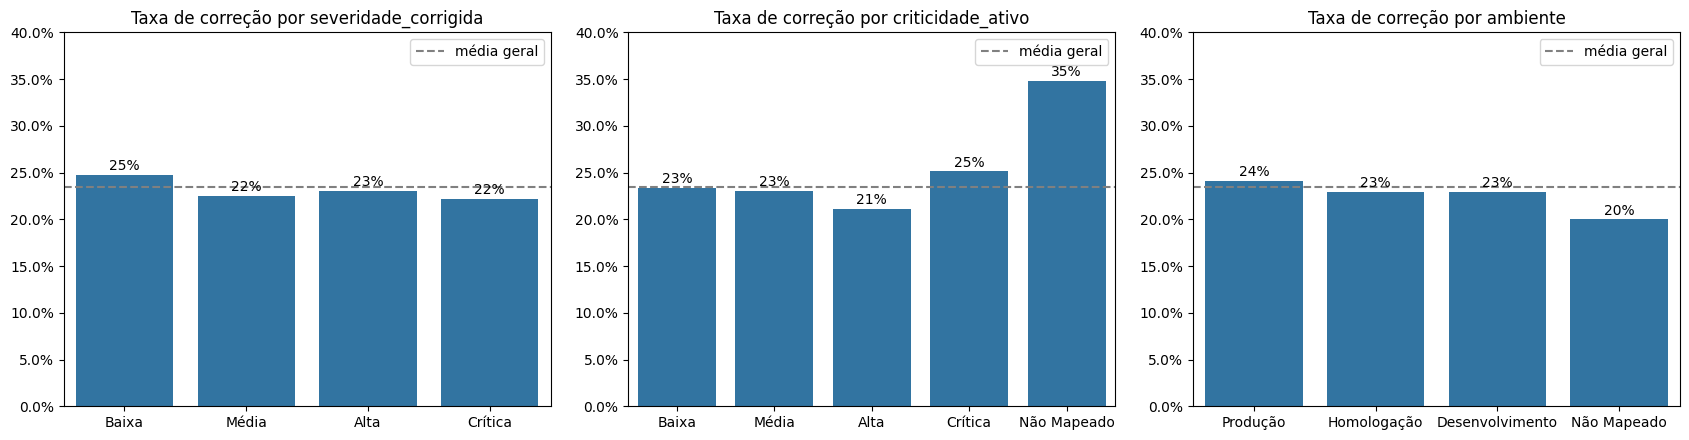

Taxa de correção geral: 23.4%


In [19]:
vulnerabilidades_df['corrigida'] = vulnerabilidades_df['status_vulnerabilidade'] == 'Corrigida'
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for a, (col, ordem) in zip(ax, [('severidade_corrigida', ORDEM_SEV), ('criticidade_ativo', ORDEM_CRIT), ('ambiente', ['Produção', 'Homologação', 'Desenvolvimento', 'Não Mapeado'])]):
    t = vulnerabilidades_df.groupby(col)['corrigida'].mean().reindex(ordem).dropna()
    sns.barplot(x=t.index, y=t.values, ax=a)
    a.axhline(vulnerabilidades_df['corrigida'].mean(), color='gray', linestyle='--', label='média geral')
    for i, v in enumerate(t.values): a.text(i, v + 0.005, f'{v:.0%}', ha='center')
    a.yaxis.set_major_formatter(PercentFormatter(1)); a.set_ylim(0, 0.4)
    a.set_title(f'Taxa de correção por {col}'); a.set_xlabel(''); a.legend()
plt.tight_layout(); plt.show()
print(f'Taxa de correção geral: {vulnerabilidades_df.corrigida.mean():.1%}')

### Tempo de correção

In [27]:
ttr = vulnerabilidades_df.dropna(subset=['dias_para_correcao'])
print(f'{len(ttr)} correções válidas de {int(vulnerabilidades_df.corrigida.sum())} marcadas como corrigidas '
      f'({int(vulnerabilidades_df.flag_data_correcao_futura.sum())} com data de correção futura)')
display(ttr.groupby('severidade_corrigida')['dias_para_correcao']
        .agg(['count', 'median', 'mean', lambda s: s.quantile(.9)]).rename(columns={'<lambda_0>': 'p90'})
        .reindex(ORDEM_SEV).round(1))

379 correções válidas de 469 marcadas como corrigidas (73 com data de correção futura)


,count,median,mean,p90
severidade_corrigida,,,,
Baixa,154,40.5,43.1,82.0
Média,119,46.0,46.1,79.2
Alta,68,41.0,43.8,83.2
Crítica,38,27.5,31.8,72.6


### Evolução mensal: entrada versus correção
Compara o volume de vulnerabilidades abertas com as corrigidas em cada mês e o backlog acumulado.

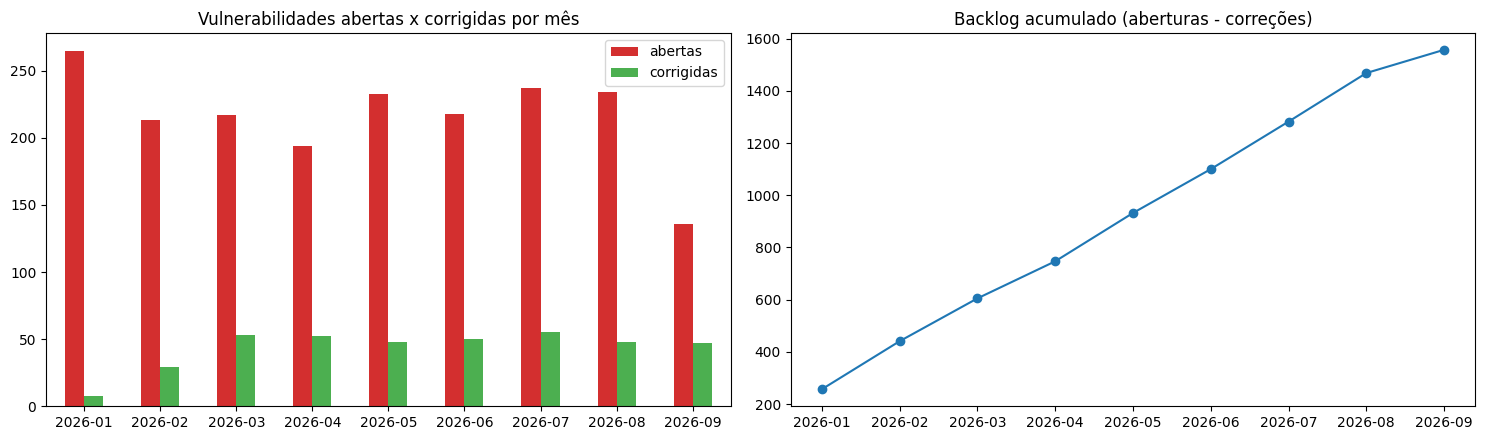

,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
abertas,265,213,217,194,233,218,237,234,136
corrigidas,8,29,53,52,48,50,55,48,47
backlog_acumulado,257,441,605,747,932,1100,1282,1468,1557


In [21]:
entradas = vulnerabilidades_df.dropna(subset=['data_abertura']).groupby(vulnerabilidades_df['data_abertura'].dt.to_period('M')).size()
saidas = (vulnerabilidades_df[vulnerabilidades_df.corrigida & ~vulnerabilidades_df.flag_data_correcao_futura].dropna(subset=['data_correcao'])
          .groupby(vulnerabilidades_df['data_correcao'].dt.to_period('M')).size())
mensal = pd.DataFrame({'abertas': entradas, 'corrigidas': saidas}).fillna(0)
mensal = mensal[mensal.index <= '2026-09']      # outubro sendo parcial
mensal['backlog_acumulado'] = (mensal.abertas - mensal.corrigidas).cumsum()
mensal.index = mensal.index.astype(str)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
mensal[['abertas', 'corrigidas']].plot(kind='bar', ax=ax[0], color=['#d32f2f', '#4caf50'])
ax[0].set_title('Vulnerabilidades abertas x corrigidas por mês'); ax[0].set_xlabel(''); ax[0].tick_params(axis='x', rotation=0)
mensal['backlog_acumulado'].plot(marker='o', ax=ax[1])
ax[1].set_title('Backlog acumulado (aberturas - correções)'); ax[1].set_xlabel('')
plt.tight_layout(); plt.show()
mensal.astype(int).T

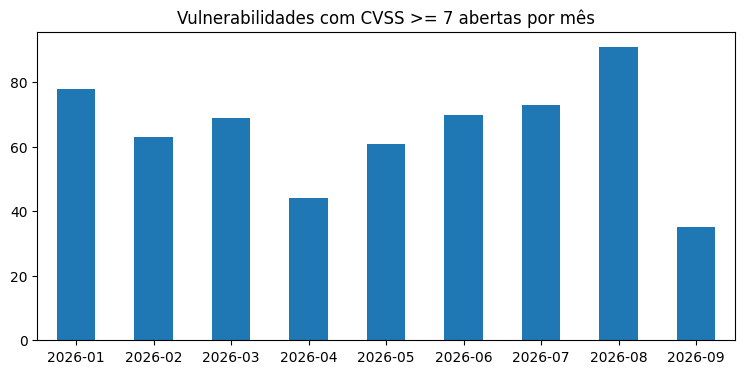

In [22]:
# Vulnerabilidades graves (CVSS >= 7) abertas por mês
graves_mes = vulnerabilidades_df[(vulnerabilidades_df.cvss_score >= 7)].dropna(subset=['data_abertura']).groupby(vulnerabilidades_df['data_abertura'].dt.to_period('M')).size()
graves_mes = graves_mes[graves_mes.index <= '2026-09']
graves_mes.index = graves_mes.index.astype(str)

graves_mes.plot(kind='bar', figsize=(9, 4))
plt.title('Vulnerabilidades com CVSS >= 7 abertas por mês')
plt.xlabel('')
plt.xticks(rotation=0)
plt.show()

### Origem das vulnerabilidades

In [23]:
(vulnerabilidades_df.groupby('origem')
   .agg(total=('vuln_id', 'size'), cvss_medio=('cvss_score', 'mean'), cvss_7_mais=('cvss_score', lambda s: int((s >= 7).sum())),
        taxa_correcao=('corrigida', 'mean'), ttr_mediano=('dias_para_correcao', 'median'))
   .assign(taxa_correcao=lambda d: d.taxa_correcao.map('{:.1%}'.format))
   .round(2))

,total,cvss_medio,cvss_7_mais,taxa_correcao,ttr_mediano
origem,,,,,
Cloud Security,506,5.11,155,23.5%,41.0
Pentest,507,4.93,158,24.7%,50.0
Qualys,465,4.95,129,23.0%,35.0
Veracode,522,5.07,161,22.6%,38.0


### Ativos com maior quantidade de vulnerabilidades
A quantidade bruta nem sempre reflete o risco. A comparação com o ranking por score mostra a diferença.

In [24]:
vol = vulnerabilidades_df[~vulnerabilidades_df.flag_ativo_orfao].groupby('ativo_id').size().rename('total_vulns')
comp = ranking.join(vol).sort_values('total_vulns', ascending=False)
comp.head(10)[['sistema', 'criticidade', 'ambiente', 'total_vulns', 'qtd_abertas', 'score']].round(1)

,sistema,criticidade,ambiente,total_vulns,qtd_abertas,score
ativo_id,,,,,,
A0086,Sistema_86,Média,Produção,20,16,209.1
A0120,Sistema_120,Alta,Produção,19,15,365.0
A0139,Sistema_139,Média,Desenvolvimento,19,16,202.4
A0057,Sistema_57,Crítica,Homologação,18,12,206.8
A0193,Sistema_193,Média,Produção,18,12,123.3
A0183,Sistema_183,Média,Produção,16,13,157.2
A0132,Sistema_132,Crítica,Desenvolvimento,15,10,226.8
A0173,Sistema_173,Alta,Produção,15,14,328.5
A0186,Sistema_186,Média,Desenvolvimento,15,11,126.8


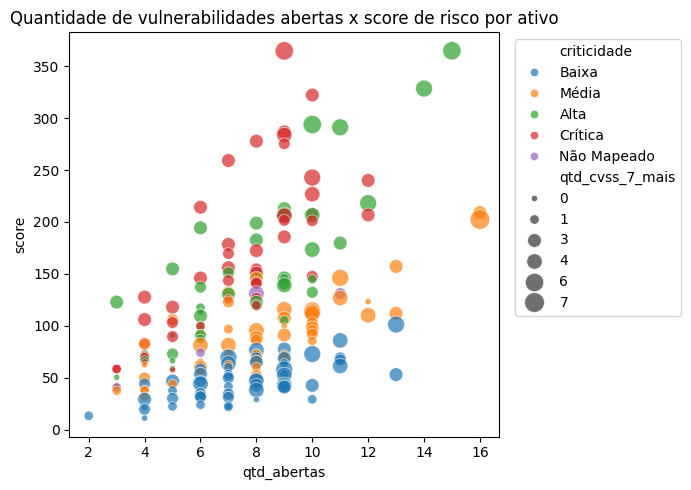

In [25]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=ranking, x='qtd_abertas', y='score', hue='criticidade', hue_order=ORDEM_CRIT,
                size='qtd_cvss_7_mais', sizes=(20, 200), alpha=.7)
plt.title('Quantidade de vulnerabilidades abertas x score de risco por ativo')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()

## Conclusões
**Exposição**
- A maior parte da base permanece sem correção, incluindo itens com CVSS elevado e itens em Produção.

**Ativos prioritários**
- O risco está distribuído por muitos ativos, sem concentração em poucos nomes. O ranking (seção 3) e a fila P1 a P4 (seção 4.2) indicam por onde começar.
- Uma parcela relevante do backlog está em ativos em desativação, o que permite reduzir risco por descomissionamento.

**Prioridade de correção**
1. Itens P1 (CVSS >= 9 em Produção ou CVSS >= 7 em ativo crítico de Produção).
2. Riscos aceitos com CVSS alto, que precisam de revisão e justificativa.
3. Ativos em desativação, com prazo de descomissionamento definido.
4. Ativos do topo do ranking de score.

**Efetividade do processo**
- A taxa de correção é baixa e praticamente igual entre severidades, criticidades e ambientes. Isso indica que o tratamento não segue o risco.
- O volume de correções mensais fica abaixo do de aberturas, de modo que o backlog acumulado cresce.
- Não há SLA formal no dado; o tempo de correção das críticas é pouco menor que o das demais.

**Recomendações**
- Adotar severidade baseada em CVSS e contexto (criticidade e ambiente) e definir SLA por prioridade.
- Instituir governança de risco aceito, com aprovador e prazo de revisão.
- Corrigir inconsistências na origem dos dados (datas, inventário de ativos, domínios de valor).
- Monitorar mensalmente backlog por prioridade, aging e taxa de correção.